In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Loading data set
df=pd.read_csv("smartcart_customers.csv")

In [67]:
df.head()

df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Pre_Processing

## 1. handling Missing Values

In [68]:
df["Income"]=df["Income"].fillna(df["Income"].median)

## 2.Feature engneering

In [69]:
# handling yearbirth
df["age"]=2026-df["Year_Birth"]

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [70]:
# handling date 
ref_date=df["Dt_Customer"].max()
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
df["customer_tenure_days"]=(ref_date-df["Dt_Customer"]).dt.days

TypeError: unsupported operand type(s) for -: 'DatetimeArray' and 'str'

In [ ]:
df.isnull().sum()

In [ ]:
df.head()

In [ ]:
# combining all products
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [ ]:
# combining children
df["total_children"]=df["Kidhome"]+df["Teenhome"]

In [ ]:
# replacing education 
df["Education"].value_counts()
df["Education"]=df["Education"].replace({"Basic":"Undergrad","2n Cycle":"Undergrad",
                         "Graduation":"Graduate",
                         "Master":"Postgrad","PhD":"Postgrad"})
                         

In [ ]:
df["living_with"]=df["Marital_Status"].replace({"Single":"ALone","Divorced":"ALone","Widow":"ALone","Alone":"ALone","Absurd":"ALone","YOLO":"ALone",
                                                "Married":"Partner","Together":"Partner"})

In [ ]:
df["living_with"].value_counts()

## 3. Drop Columns

In [ ]:
df.head()

In [ ]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
prod_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
total_cols=cols + prod_cols
cleaned_df=df.drop(columns=total_cols)


In [ ]:
cleaned_df.head()
cleaned_df.info()

## 4.outliers

In [ ]:
# numerical_cols
cols = [ "Recency","Income","Response", "age", "Total_Spending", "total_children"]
sns.pairplot(cleaned_df[cols])
plt.savefig("Pair_plots for detecting outliers.png")

In [72]:
# removing some outliers
cleaned_df=cleaned_df[(cleaned_df["Income"] < 600000)]
cleaned_df=cleaned_df[(cleaned_df["age"] < 90)]

In [73]:
cleaned_df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenure_days,Total_Spending,total_children,living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,ALone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,ALone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgrad,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# heat map

In [74]:
corr=cleaned_df.corr(numeric_only=True)

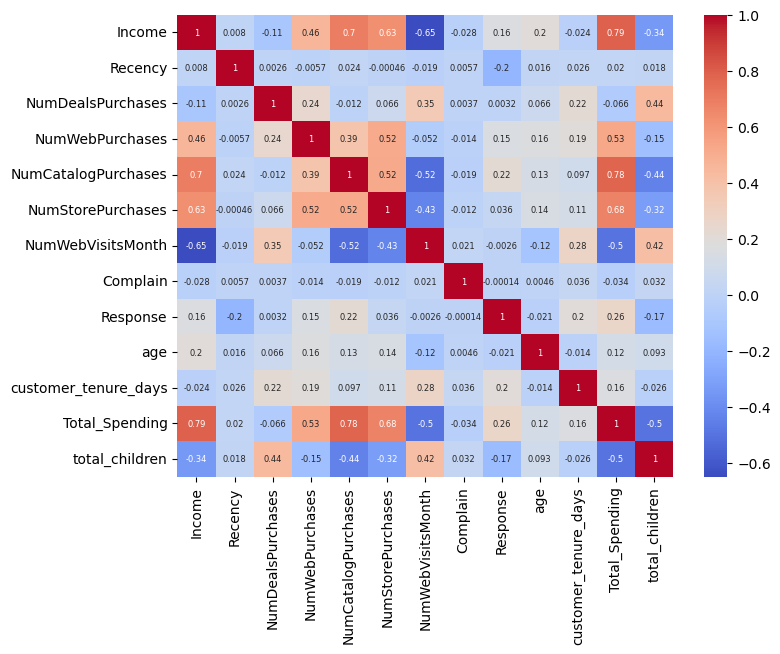

In [76]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,annot=True,annot_kws={"size": 6},
    cmap="coolwarm")
plt.savefig("Heatmap.png")

# Encoding

In [78]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2212 non-null   object 
 1   Income                2212 non-null   float64
 2   Recency               2212 non-null   int64  
 3   NumDealsPurchases     2212 non-null   int64  
 4   NumWebPurchases       2212 non-null   int64  
 5   NumCatalogPurchases   2212 non-null   int64  
 6   NumStorePurchases     2212 non-null   int64  
 7   NumWebVisitsMonth     2212 non-null   int64  
 8   Complain              2212 non-null   int64  
 9   Response              2212 non-null   int64  
 10  age                   2212 non-null   int64  
 11  customer_tenure_days  2212 non-null   int64  
 12  Total_Spending        2212 non-null   int64  
 13  total_children        2212 non-null   int64  
 14  living_with           2212 non-null   object 
dtypes: float64(1), int64(12), 

In [79]:
cols=["living_with","Education"]

In [88]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
encoded_cols=ohe.fit_transform(cleaned_df[cols])
enc_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cols),index=cleaned_df.index)

In [90]:
encoded_df=pd.concat([cleaned_df.drop(columns=cols),enc_df],axis=1)

In [91]:
encoded_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenure_days,Total_Spending,total_children,living_with_ALone,living_with_Partner,Education_Graduate,Education_Postgrad,Education_Undergrad
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,1.0,0.0


# Scaling

In [94]:
x=encoded_df
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

# PCA technique

In [97]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

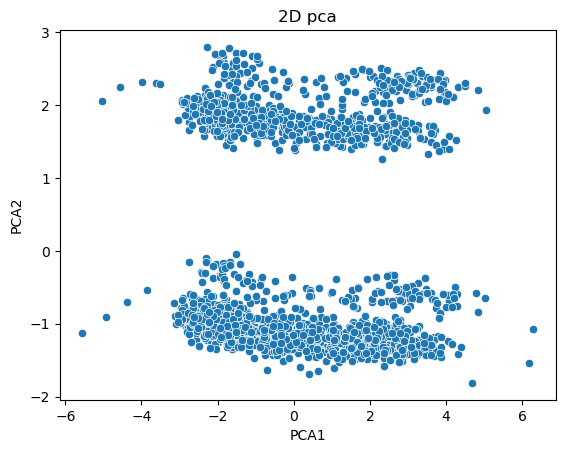

In [102]:
ax=sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_title("2D pca")
plt.savefig("2D PCA")

In [103]:
pca.explained_variance_ratio_  #low variance for 2d

array([0.23258254, 0.11390916])

## 3D PCA

In [104]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

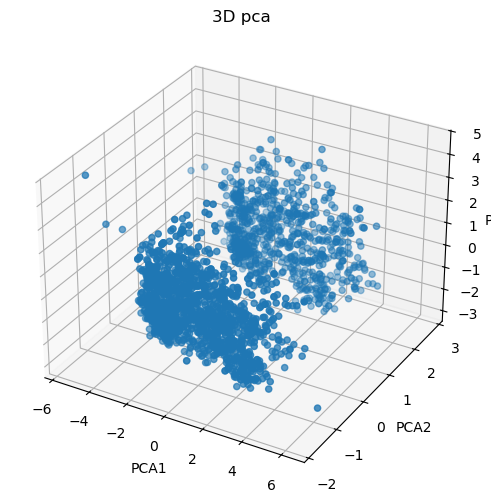

In [110]:
fig = plt.figure(figsize=(8, 6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D pca")
plt.savefig("3D PCA")

In [111]:
pca.explained_variance_ratio_  #high variance for 3d

array([0.23258254, 0.11390916, 0.10418299])

# Finding Value of K

## Elbow Method

In [113]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,10):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
    

In [115]:
from kneed import KneeLocator
knee=KneeLocator(range(1,10),wcss,curve="convex", direction="decreasing")

In [118]:
optimal_k=knee.elbow

In [120]:
print("Best value of k:",optimal_k)

Best value of k: 4


# Clustering

In [121]:
# kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
km_labels=kmeans.fit_predict(x_pca)

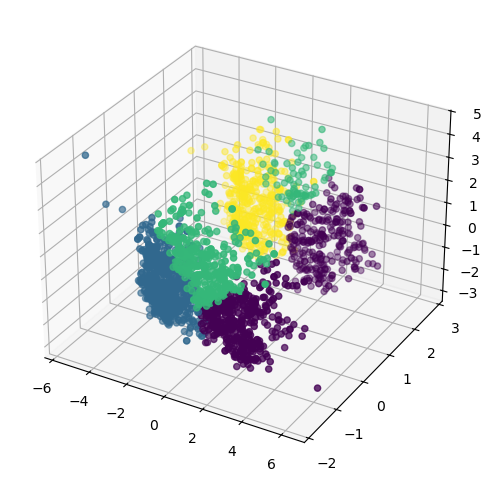

In [123]:
fig = plt.figure(figsize=(8, 6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=km_labels)
plt.savefig("KMeans Clusters")

## Agglomerative Clustering

In [127]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels=agg.fit_predict(x_pca)

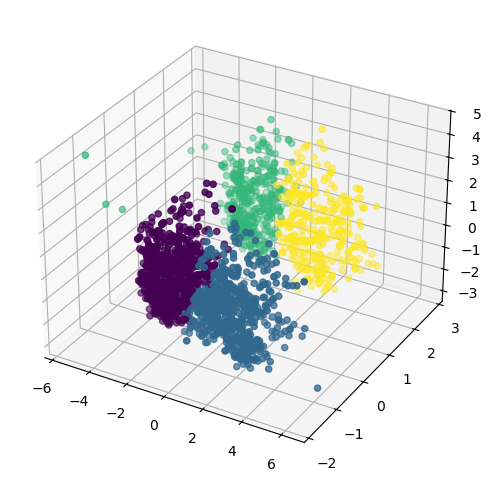

In [129]:
fig = plt.figure(figsize=(8, 6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=agg_labels)
plt.savefig("Agglomerative  Clusters")

# characterization of clusters


In [130]:
x["clusters"]=agg_labels

In [131]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_tenure_days,Total_Spending,total_children,living_with_ALone,living_with_Partner,Education_Graduate,Education_Postgrad,Education_Undergrad,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,1.0,0.0,0


In [132]:
pal=["red","green","blue","yellow"]

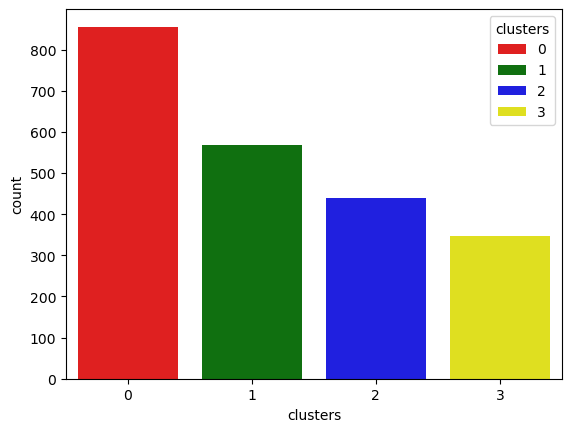

In [134]:
sns.countplot(x=x["clusters"],palette=pal,hue=x["clusters"])
plt.savefig("Countplots for clusters.png")

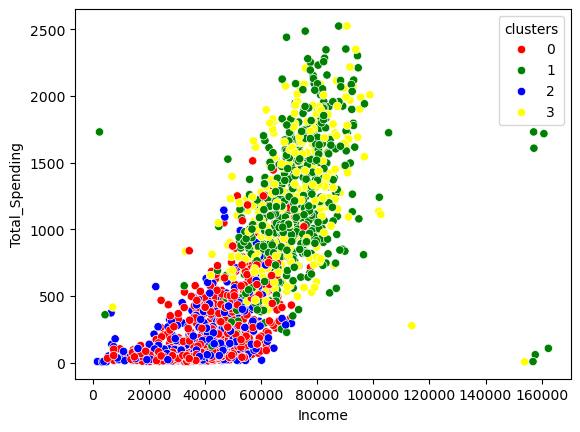

In [136]:
sns.scatterplot(x=x["Income"],y=x["Total_Spending"],hue=x["clusters"],palette=pal)
plt.savefig("scatterplot for income vs total_spending.png")

In [135]:
x.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'customer_tenure_days', 'Total_Spending',
       'total_children', 'living_with_ALone', 'living_with_Partner',
       'Education_Graduate', 'Education_Postgrad', 'Education_Undergrad',
       'clusters'],
      dtype='object')

# Summary of clusters

In [137]:
cluster_summary=x.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         38814.688084  49.113318           2.643692         3.063084   
1         71785.449912  48.810193           1.919156         5.662566   
2         36861.452273  48.034091           2.600000         2.736364   
3         71016.011527  50.380403           1.853026         5.749280   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.941589           4.070093           6.477804  0.009346   
1                    5.230228           8.469244           3.520211  0.008787   
2                    0.854545           3.643182           6.659091  0.011364   
3                    5.051873           8.466859           3.726225  0.005764   

          Response        age  customer_tenure_days  Total_Spending  \
clu